# Logistic Regression Model Evaluation

This notebook trains a logistic regression classifier and evaluates it with confusion matrix, precision-recall, ROC, and ROC-AUC analysis.


### Build and Train the Baseline Model


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.metrics import accuracy_score

df = pd.read_csv("/content/titanic.csv")

#cols = ['survived', 'sex', 'embarked', 'class', 'age', 'fare']
# survived: 0 = No, 1 = Yes
# embarked: C = Cherbourg, Q = Queenstown, S = Southampton

# Separate the features and target variable
X = df.drop("survived", axis=1)
y = df["survived"]

# Categorical and numerical features
categorical = ['sex', 'embarked', 'class']
numerical = ['age', 'fare']


# transform the dataset using a column transformer
ct = make_column_transformer(
    (StandardScaler(), numerical),
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical)
)

# Fit the column transformer to the training data
X_transformed = ct.fit_transform(X)

# Instantiate the logistic regression model
clf = LogisticRegression(max_iter=1000)

# Step 1: Get the scores of the cross-validate with 5 folds
scores = cross_val_score(clf, X_transformed, y, cv=5)

# Step 2: Print the scores

print("Cross-validation scores:", scores)
# Step 3: print the mean of the scores
print("Mean accuracy:", scores.mean())


Cross-validation scores: [0.72727273 0.83916084 0.76056338 0.76760563 0.81690141]
Mean accuracy: 0.7823007977937555


---

### Confusion Matrix and Classification Metrics


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report

df = pd.read_csv("/content/titanic.csv")

#cols = ['survived', 'sex', 'embarked', 'class', 'age', 'fare']
# survived: 0 = No, 1 = Yes
# embarked: C = Cherbourg, Q = Queenstown, S = Southampton

# Separate the features and target variable
X = df.drop("survived", axis=1)
y = df["survived"]

# Categorical and numerical features
categorical = ['sex', 'embarked', 'class']
numerical = ['age', 'fare']


# transform the dataset using a column transformer
ct = make_column_transformer(
    (StandardScaler(), numerical),
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical)
)

# apply the column transformer to the dataset
X_transformed = ct.fit_transform(X)

# prepare the logistic regression model
clf = LogisticRegression(max_iter=1000)

# partition the dataset for training and testing
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, random_state=42)
# Step 1: Fit the model to the training data
clf.fit(X_train, y_train)

# Step 2: make y_pred using the model on the test data
y_pred = clf.predict(X_test)
# Step 3: print the accuracy score, confusion matrix, and classification report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7752808988764045
Confusion Matrix:
 [[85 14]
 [26 53]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.86      0.81        99
           1       0.79      0.67      0.73        79

    accuracy                           0.78       178
   macro avg       0.78      0.76      0.77       178
weighted avg       0.78      0.78      0.77       178



---

### Precision-Recall Curve


Average Precision Score: 0.7904172291438474


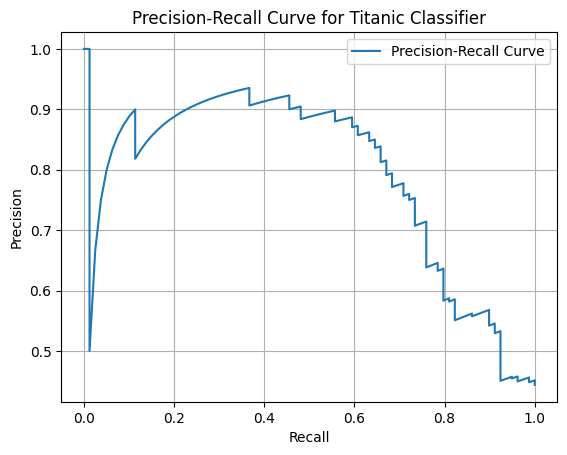

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import make_column_transformer
from sklearn.metrics import accuracy_score, precision_recall_curve,average_precision_score
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/titanic.csv")

# Separate features and target
X = df.drop("survived", axis=1)
y = df["survived"]

# Define categorical and numerical columns
categorical = ['sex', 'embarked', 'class']
numerical = ['age', 'fare']

# Column transformer for preprocessing
ct = make_column_transformer(
    (StandardScaler(), numerical),
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical)
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Fit and transform
ct.fit(X_train)
X_train_transformed = ct.transform(X_train)
X_test_transformed = ct.transform(X_test)

# Train logistic regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_transformed, y_train)

# Predict probabilities for PR curve
y_scores = clf.predict_proba(X_test_transformed)[:, 1]  # probability for class 1 (survived)

# Step 1: Compute precision-recall curve using precision_recall_curve()

precision, recall, _ = precision_recall_curve(y_test, y_scores)
# Step 2: Compute average precision score using average_precision_score()
avg_precision = average_precision_score(y_test, y_scores)
print("Average Precision Score:", avg_precision)


# Plotting the curve
plt.plot(recall, precision, label="Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Titanic Classifier")
plt.legend()
plt.grid(True)
plt.show()


### ROC Curve and ROC-AUC


ROC AUC Score: 0.8082086689681627


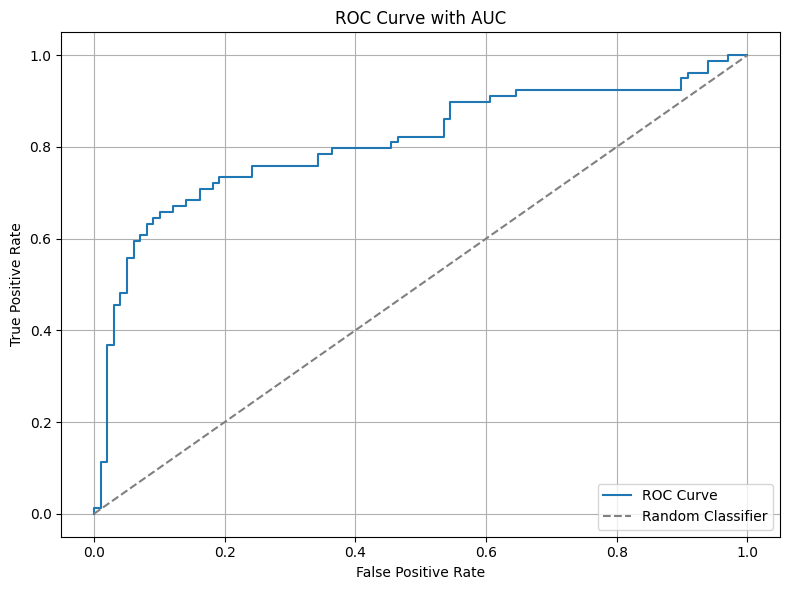

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import make_column_transformer
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/titanic.csv")

# Features and target
X = df.drop("survived", axis=1)
y = df["survived"]

# Feature types
categorical = ['sex', 'embarked', 'class']
numerical = ['age', 'fare']

# Preprocessing
ct = make_column_transformer(
    (StandardScaler(), numerical),
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical)
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Transform
ct.fit(X_train)
X_train_transformed = ct.transform(X_train)
X_test_transformed = ct.transform(X_test)

# Train model
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_transformed, y_train)

# Predict probabilities
y_scores = clf.predict_proba(X_test_transformed)[:, 1]

# Step 1: Compute ROC curve using roc_curve()
fpr, tpr, _ = roc_curve(y_test, y_scores)

# Step 2: Compute AUC using roc_auc_score

auc = roc_auc_score(y_test, y_scores)
print("ROC AUC Score:", auc)
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0, 1], [0, 1], '--', color='gray', label="Random Classifier")

# Labels and layout
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with AUC")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()
